In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.style
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.cm as cmx
mpl.style.use('classic')

import baraffe_tables
from baraffe_tables.table_search import baraffe_table_search

from astropy.table import Table
from astropy import units as u
from astropy.constants import G

import mesa_helper as mh
import os
import shutil

%matplotlib inline

In [2]:
mJtomSun = u.jupiterMass.to(u.solMass)
mJtoGrams = u.jupiterMass.to(u.g)

rJtorSun = u.jupiterRad.to(u.solRad)
rSuntorJ = u.solRad.to(u.jupiterRad)
rJtoCm = u.jupiterRad.to(u.cm)

#print(mJtomSun)
print(20.0*mJtoGrams)
#print(rJtorSun)
print(2*rJtoCm)


3.796249194672101e+31
14298400000.0


In [3]:
#eos_choices = ['MESA_default','CD21+AQUA_orig_meos_implementation','CMS19_orig_meos_implementation','CMS19_TC_s=1','CMS19_control_s=1_sf=0.05','CMS19_control_s=1_sf=0.1','CMS19_control_s=1_sf=0.25','CMS19_TC_s=2','CMS19_control_s=2_sf=0.05','CMS19_control_s=2_sf=0.1','CMS19_control_s=2_sf=0.25']#,'CMS19_TC_s=5','CMS19_control_s=5_sf=0.05','CMS19_control_s=5_sf=0.1','CMS19_control_s=5_sf=0.25']
#colors = ['k','m','b','g','g','g','g','y','y','y','y','r','r','r','r']
#ls = ['-','-','-','-','--','-.',':','-','--','-.',':','-','--','-.',':']


eos_choices = ['CMS19_orig_meos_implementation','CMS19_control_s=2_sf=0.1','CMS19_TC_s=2']
labels = ['original', 'control', 'F-derived']
colors = ['k','k','b']
ls = ['-','--','-']



#colors=['k','b','r','r']
#ls=['-','-','-',':']
print(eos_choices)

comps = ['protosolar']
comp_profiles = ['uniform','exponential']

#Minit = np.array((10.0,5.0,1.0))
Minit = np.atleast_1d(np.array((5.0)))


#Rinit = np.array((2.0,5.0))
Rinit = np.atleast_1d(np.array((2.0)))

Sinit = np.atleast_1d(np.array((10.0)))


['CMS19_orig_meos_implementation', 'CMS19_control_s=2_sf=0.1', 'CMS19_TC_s=2']


In [4]:
history_filename = "./eos_MESA_default/planet_5.0Gyr_5.0_Mj_2.0_Rj_protosolar.history"
history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
print(history.colnames)

['model_number', 'num_zones', 'star_age', 'log_dt', 'star_mass', 'mass_conv_core', 'Teff', 'luminosity', 'radius', 'log_g', 'log_cntr_P', 'log_cntr_Rho', 'log_cntr_T', 'center_degeneracy', 'center_entropy', 'average_h1', 'average_he3', 'average_he4', 'average_c12', 'average_n14', 'average_o16', 'average_ne20', 'average_mg24', 'total_mass_h1', 'total_mass_he4', 'delta_nu', 'nu_max', 'acoustic_cutoff', 'acoustic_radius', 'tot_E', 'tot_PE', 'tot_IE', 'total_entropy', 'total_eps_grav', 'total_energy_sources_and_sinks', 'rel_run_E_err', 'rel_E_err', 'tot_E_equ_err', 'tot_E_err', 'error_in_energy_conservation', 'cumulative_energy_error', 'rel_cumulative_energy_error', 'rel_error_in_energy_conservation', 'virial_thm_rel_err', 'num_retries', 'num_iters']


In [5]:
profile_filename = "./eos_MESA_default/planet_5.0_Mj_2.0_Rj_protosolar.terminationprofile"
profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
print(profile.colnames)

['zone', 'mass', 'logR', 'logT', 'logRho', 'logP', 'x_mass_fraction_H', 'y_mass_fraction_He', 'z_mass_fraction_metals', 'dm', 'q', 'xq', 'radius', 'rmid', 'acoustic_radius', 'temperature', 'energy', 'entropy', 'pressure', 'prad', 'pgas', 'grada', 'log_csound', 'h1', 'he3', 'he4', 'c12', 'n14', 'o16', 'ne20', 'mg24', 'total_energy', 'ergs_error', 'ergs_error_integral', 'ergs_rel_error_integral', 'dm_eps_grav', 'dE', 'log_rel_E_err', 'gradT', 'gradr', 'gradL', 'sch_stable', 'ledoux_stable', 'mixing_type', 'tau', 'brunt_N2', 'brunt_N2_structure_term', 'brunt_N2_composition_term', 'log_brunt_N2_structure_term', 'log_brunt_N2_composition_term', 'brunt_A', 'brunt_A_div_x2', 'brunt_N2_dimensionless', 'brunt_N_dimensionless', 'brunt_frequency', 'brunt_N', 'log_brunt_N', 'log_brunt_N2', 'log_brunt_N2_dimensionless', 'brunt_B', 'brunt_nonB', 'log_brunt_B', 'log_brunt_nonB', 'sign_brunt_N2', 'brunt_nu', 'log_brunt_nu', 'lamb_S', 'lamb_S2', 'lamb_Sl1', 'lamb_Sl2', 'lamb_Sl3', 'lamb_Sl10', 'log_lam

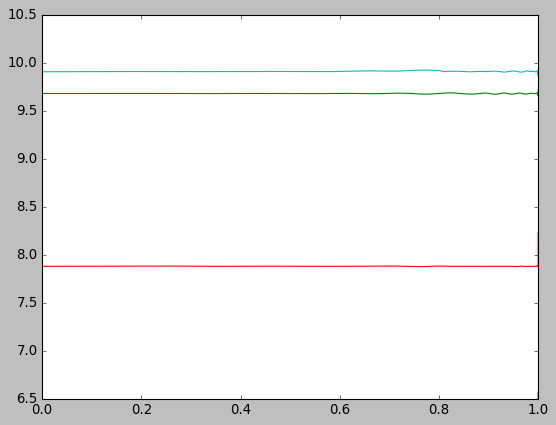

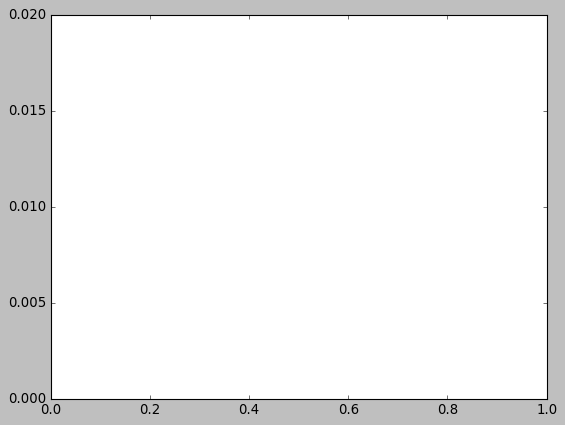

[]


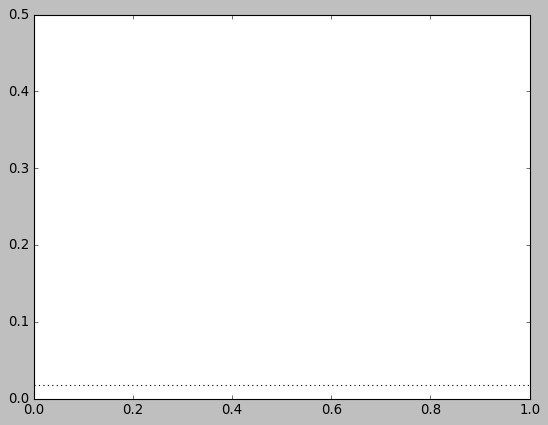

In [17]:
model_dir = "/Users/emily/Documents/astro/giant_planets/MESA_EoS/thermo_consistency/MESA_runs/eos_CMS19_orig_meos_implementation/LOGS"

profilefiles = [f for f in os.listdir(model_dir) if os.path.isfile(os.path.join(model_dir, f)) and "planet_5.0Gyr_5.0_Mj_2.0_Rj_protosolar_profile" in f]
profilefiles = profilefiles[::-1]

cs = ['b','g','r','c']

fig, ax = plt.subplots(1,1,figsize=(8,6))
for i,f in enumerate(profilefiles):
    fname = model_dir + "/" + f
    profile = Table.read(fname, format="ascii", header_start=4, data_start=5)
    ax.plot(profile['q'],profile['entropy'],color=cs[i])
ax.set_ylim(6.5,10.5)
plt.show()
    
profilefiles = [f for f in os.listdir(model_dir) if os.path.isfile(os.path.join(model_dir, f)) and "planet_5.0Gyr_5.0_Mj_2.0_Rj_protosolar_uniform_9.0_profile" in f]
#profilefiles = [profilefiles[1],profilefiles[0],profilefiles[2]]

cs = ['b','g','r','c']

fig, ax = plt.subplots(1,1,figsize=(8,6))
for i,f in enumerate(profilefiles):
    fname = model_dir + "/" + f
    print(fname)
    profile = Table.read(fname, format="ascii", header_start=4, data_start=5)
    ax.plot(profile['q'],profile['z_mass_fraction_metals'],color=cs[i])
ax.set_ylim(0.,0.02)
plt.show()

profilefiles = [f for f in os.listdir(model_dir) if os.path.isfile(os.path.join(model_dir, f)) and "planet_5.0Gyr_5.0_Mj_2.0_Rj_protosolar_exponential_9.0_profile" in f]
print(profilefiles)
#profilefiles = [profilefiles[1],profilefiles[0],profilefiles[2]]

cs = ['b','g','r','c','m','y']

fig, ax = plt.subplots(1,1,figsize=(8,6))
for i,f in enumerate(profilefiles):
    fname = model_dir + "/" + f
    print(fname)
    profile = Table.read(fname, format="ascii", header_start=4, data_start=5)
    ax.plot(profile['q'],profile['z_mass_fraction_metals'],color=cs[i])
    
    #ax.plot(profile['q'],profile['x_mass_fraction_H']+profile['y_mass_fraction_He'],color=cs[i])
ax.set_ylim(0.,0.5)
ax.axhline(0.017,color='k',ls=':')
plt.show()
    

In [18]:
compfile = './eos_MESA_default/composition_5.0_Mj_2.0_Rj_protosolar_exponential_8.0.dat'
comp = np.genfromtxt(compfile,skip_header=1)
print(np.shape(comp))
zs = np.sum(comp[:,5:],axis=1)
print(np.shape(zs))
fig, ax = plt.subplots(1,1,figsize=(8,6))
ax.plot(1-comp[:,0],zs)
plt.show()

FileNotFoundError: ./eos_MESA_default/composition_5.0_Mj_2.0_Rj_protosolar_exponential_8.0.dat not found.

no CMS19_orig_meos_implementation
no CMS19_TC_s=2


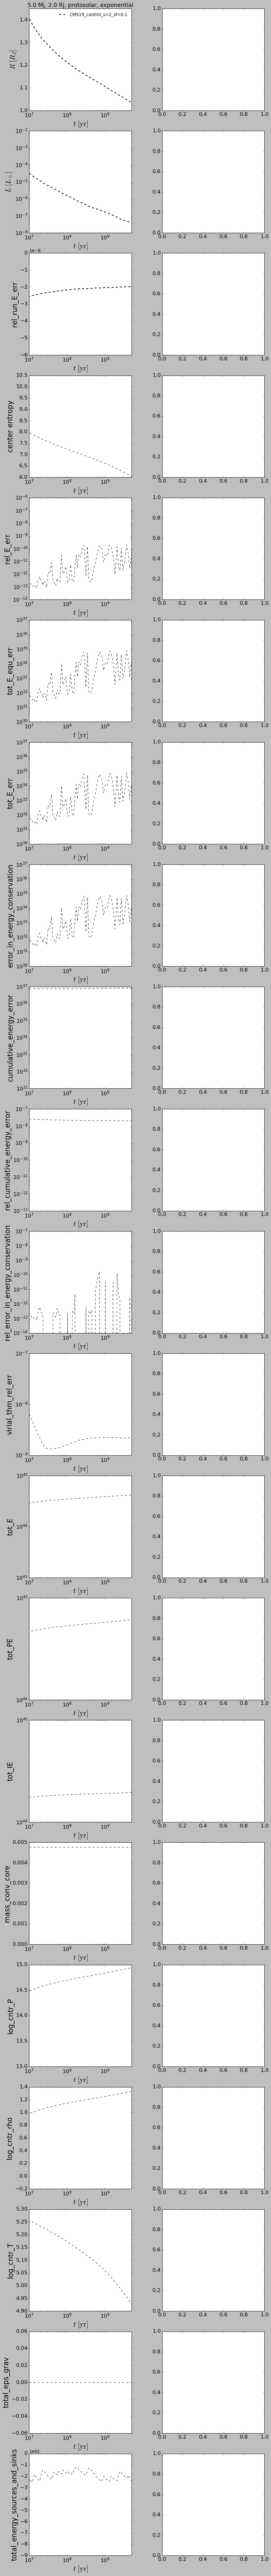

In [19]:
#fig, axes = plt.subplots(3,len(Minit),figsize=(24,16))
nrow = 21
fig, axes = plt.subplots(nrow,len(Minit)+1,figsize=(6*(len(Minit)+1),6*nrow))

for ii in range(len(Minit)):
    for jj in range(nrow):
        axes[jj,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
        axes[jj,ii].set_xscale('log')
        axes[jj,ii].set_xlim(1.e7,5.e9)

    axes[0,ii].set_ylabel(r"$R\ [R_J]$",fontsize=20)
    axes[1,ii].set_ylabel(r"$L\ [L_\odot]$",fontsize=20)
    axes[2,ii].set_ylabel(r"rel_run_E_err",fontsize=20)
    axes[3,ii].set_ylabel(r"center entropy",fontsize=20)
    axes[4,ii].set_ylabel(r"rel_E_err",fontsize=20)
    axes[5,ii].set_ylabel(r"tot_E_equ_err",fontsize=20)
    axes[6,ii].set_ylabel(r"tot_E_err",fontsize=20)
    axes[7,ii].set_ylabel(r"error_in_energy_conservation",fontsize=20)
    axes[8,ii].set_ylabel(r"cumulative_energy_error",fontsize=20)
    axes[9,ii].set_ylabel(r"rel_cumulative_energy_error",fontsize=20)
    axes[10,ii].set_ylabel(r"rel_error_in_energy_conservation",fontsize=20)
    axes[11,ii].set_ylabel(r"virial_thm_rel_err",fontsize=20)
    axes[12,ii].set_ylabel(r"tot_E",fontsize=20)
    axes[13,ii].set_ylabel(r"tot_PE",fontsize=20)
    axes[14,ii].set_ylabel(r"tot_IE",fontsize=20)
    axes[15,ii].set_ylabel(r"mass_conv_core",fontsize=20)
    axes[16,ii].set_ylabel(r"log_cntr_P",fontsize=20)
    axes[17,ii].set_ylabel(r"log_cntr_rho",fontsize=20)
    axes[18,ii].set_ylabel(r"log_cntr_T",fontsize=20)
    axes[19,ii].set_ylabel(r"total_eps_grav",fontsize=20)
    axes[20,ii].set_ylabel(r"total_energy_sources_and_sinks",fontsize=20)
    #axes[2,ii].set_xlabel(r"$\log_{10}T\ [\mathrm{K}]$",fontsize=20)
    #axes[2,ii].set_ylabel(r"$\log_{10}P\ [\mathrm{bar}]$",fontsize=20)
    
    axes[0,ii].set_ylim(1.,1.45)

    axes[1,ii].set_yscale('log')

    axes[4,ii].set_ylim(1.e-12,1.e-4)

    axes[4,ii].set_ylim(1.e-14,1.e-6)

    for jj in range(4,15):
        axes[jj,ii].set_yscale('log')

    
    
for ax in np.ravel(axes):
    ax.tick_params(axis='both', which='major', labelsize=15)

for j, m in enumerate(Minit):
    for k, comp in enumerate(comps):
        for l, r in enumerate(Rinit):
            for ii, prof in enumerate(comp_profiles[1:2]):
                for jj, s in enumerate(Sinit):
                    axes[0,j].set_title("{0} Mj, {1} Rj, {2}, {3}".format(m,r,comp,prof),fontsize=16)
                    """
                    try:     
                        history_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/LOGS/planet_5.0Gyr_{0}_Mj_{1}_Rj_{2}_mespa.history".format(m,r,comp)
                        
                        history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
                    
                        axes[0,j].plot(history['star_age'],history['radius']*rSuntorJ,color='#008B8B',ls='-')
                        axes[1,j].plot(history['star_age'],history['luminosity'],color='#008B8B',ls='-',label='MESPA')
                        '''
                        profile_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/planet_5.0Gyr_{0}_Mj_{1}_Rj_{2}_mespa.profile".format(m,r,comp)
                        
                        profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
                    
                        axes[2,j].plot(profile['logT'],profile['logP']-6,color='#008B8B',ls='-',label='MESPA')
                        '''
                    except FileNotFoundError:
                        print("no mespa for {0}".format(m))
                    """
                    for i,e in enumerate(eos_choices):
            
                        try:
                            history_filename = "./eos_{0}/planet_5.0Gyr_{1}_Mj_{2}_Rj_{3}_{4}_{5}.history".format(e,m,r,comp,prof,s)
                            #history_filename = "./eos_{0}/planet_5.0Gyr_{1}_Mj_{2}_Rj_{3}.history".format(e,m,r,comp)
                            history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
                            #print(history['rel_run_E_err'])

                            
                            axes[0,j].plot(history['star_age'],history['radius']*rSuntorJ,color=colors[i],ls=ls[i],lw=2,label=e)#labels[i])
                            #axes[0,j].plot(history['star_age'],history['Teff'],color=colors[i],ls=ls[i])
                            axes[1,j].plot(history['star_age'],history['luminosity'],color=colors[i],ls=ls[i],lw=2)
                            axes[2,j].plot(history['star_age'],history['rel_run_E_err'],color=colors[i],ls=ls[i],lw=2)

                            axes[3,j].plot(history['star_age'],history['center_entropy'],color=colors[i],ls=ls[i])
                            
                            #axes[3,j].plot(history['star_age'],np.abs(history['rel_run_E_err']),color=colors[i],ls=ls[i],label=e)
                            
                            axes[4,j].plot(history['star_age'],np.abs(history['rel_E_err']),color=colors[i],ls=ls[i],label=e)
                            axes[5,j].plot(history['star_age'],np.abs(history['tot_E_equ_err']),color=colors[i],ls=ls[i],label=e)
                            axes[6,j].plot(history['star_age'],np.abs(history['tot_E_err']),color=colors[i],ls=ls[i],label=e)
                            axes[7,j].plot(history['star_age'],np.abs(history['error_in_energy_conservation']),color=colors[i],ls=ls[i],label=e)
                            axes[8,j].plot(history['star_age'],(history['cumulative_energy_error']),color=colors[i],ls=ls[i],label=e)
                            axes[9,j].plot(history['star_age'],(history['rel_cumulative_energy_error']),color=colors[i],ls=ls[i],label=e)
                            axes[10,j].plot(history['star_age'],(history['rel_error_in_energy_conservation']),color=colors[i],ls=ls[i],label=e)
                            axes[11,j].plot(history['star_age'],np.abs(history['virial_thm_rel_err']),color=colors[i],ls=ls[i],label=e)
                            axes[12,j].plot(history['star_age'],-1*history['tot_E'],color=colors[i],ls=ls[i],label=e)
                            axes[13,j].plot(history['star_age'],-1*history['tot_PE'],color=colors[i],ls=ls[i],label=e)
                            axes[14,j].plot(history['star_age'],history['tot_IE'],color=colors[i],ls=ls[i],label=e)
                            
                            axes[15,j].plot(history['star_age'],history['mass_conv_core'],color=colors[i],ls=ls[i],label=e)
                            axes[16,j].plot(history['star_age'],history['log_cntr_P'],color=colors[i],ls=ls[i],label=e)
                            axes[17,j].plot(history['star_age'],history['log_cntr_Rho'],color=colors[i],ls=ls[i],label=e)
                            axes[18,j].plot(history['star_age'],history['log_cntr_T'],color=colors[i],ls=ls[i],label=e)
                            axes[19,j].plot(history['star_age'],history['total_eps_grav'],color=colors[i],ls=ls[i],label=e)
                            axes[20,j].plot(history['star_age'],history['total_energy_sources_and_sinks'],color=colors[i],ls=ls[i],label=e)
    


                            '''
                            profile_filename = "./eos_{0}/planet_1.0Gyr_{1}_Mj_{2}.profile".format(e,m,comp)
                            profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
                
                            axes[2,j].plot(profile['logT'],profile['logP']-6,color=colors[i],ls=ls[i],label=e)
                            '''
                            axes[0,j].legend(loc='upper right',frameon=False,fontsize=12)
                        except FileNotFoundError:
                            print("no {0}".format(e))
            
plt.subplots_adjust(hspace=0.2,wspace=0.3)
plt.show()

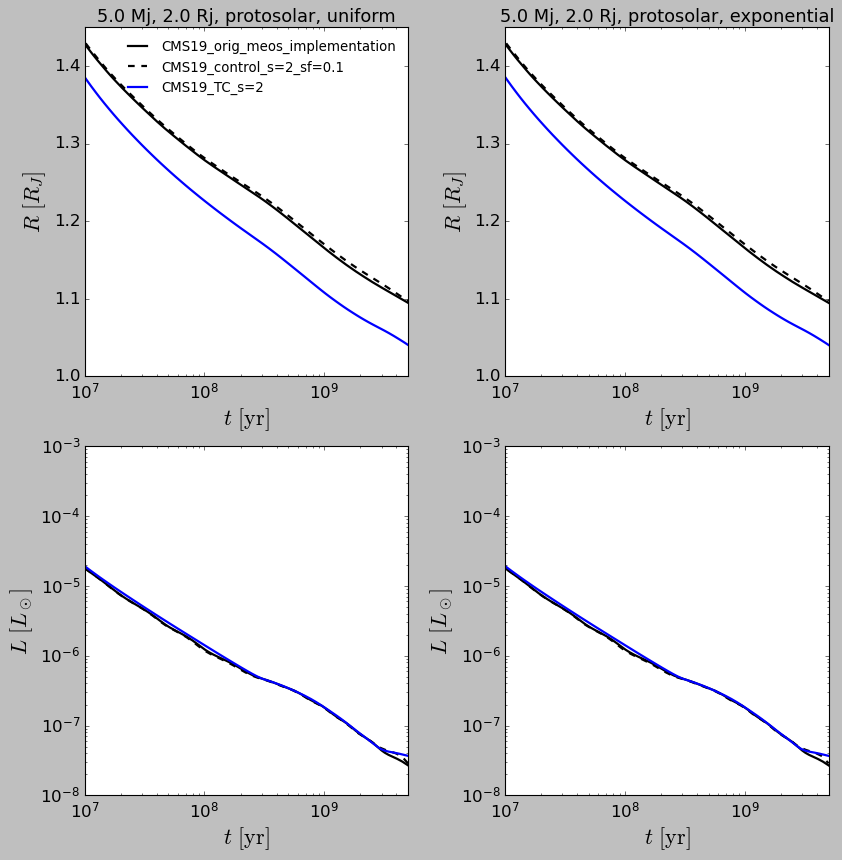

In [20]:
#fig, axes = plt.subplots(3,len(Minit),figsize=(24,16))
fig, axes = plt.subplots(2,2,figsize=(12,12))

for ii in range(2):
    for jj in range(2):
        axes[jj,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
        axes[jj,ii].set_xscale('log')
        axes[jj,ii].set_xlim(1.e7,5.e9)

    axes[0,ii].set_ylabel(r"$R\ [R_J]$",fontsize=20)
    axes[1,ii].set_ylabel(r"$L\ [L_\odot]$",fontsize=20)
    
    axes[0,ii].set_ylim(1.,1.45)

    axes[1,ii].set_yscale('log')

    
for ax in np.ravel(axes):
    ax.tick_params(axis='both', which='major', labelsize=15)

for j, m in enumerate(Minit):
    for k, comp in enumerate(comps):
        for l, r in enumerate(Rinit):
            for ii, prof in enumerate(comp_profiles):
                for jj, s in enumerate(Sinit):
                    axes[0,ii].set_title("{0} Mj, {1} Rj, {2}, {3}".format(m,r,comp,prof),fontsize=16)
                    """
                    try:     
                        history_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/LOGS/planet_5.0Gyr_{0}_Mj_{1}_Rj_{2}_mespa.history".format(m,r,comp)
                        
                        history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
                    
                        axes[0,j].plot(history['star_age'],history['radius']*rSuntorJ,color='#008B8B',ls='-')
                        axes[1,j].plot(history['star_age'],history['luminosity'],color='#008B8B',ls='-',label='MESPA')
                        '''
                        profile_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/planet_5.0Gyr_{0}_Mj_{1}_Rj_{2}_mespa.profile".format(m,r,comp)
                        
                        profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
                    
                        axes[2,j].plot(profile['logT'],profile['logP']-6,color='#008B8B',ls='-',label='MESPA')
                        '''
                    except FileNotFoundError:
                        print("no mespa for {0}".format(m))
                    """
                    for i,e in enumerate(eos_choices):
            
                        try:
                            #history_filename = "./eos_{0}/planet_5.0Gyr_{1}_Mj_{2}_Rj_{3}_{4}_{5}.history".format(e,m,r,comp,prof,s)
                            history_filename = "./eos_{0}/planet_5.0Gyr_{1}_Mj_{2}_Rj_{3}.history".format(e,m,r,comp)
                            history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
                            #print(history['rel_run_E_err'])

                            
                            axes[0,ii].plot(history['star_age'],history['radius']*rSuntorJ,color=colors[i],ls=ls[i],lw=2,label=e)#labels[i])
                            #axes[0,j].plot(history['star_age'],history['Teff'],color=colors[i],ls=ls[i])
                            axes[1,ii].plot(history['star_age'],history['luminosity'],color=colors[i],ls=ls[i],lw=2)


                            '''
                            profile_filename = "./eos_{0}/planet_1.0Gyr_{1}_Mj_{2}.profile".format(e,m,comp)
                            profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
                
                            axes[2,j].plot(profile['logT'],profile['logP']-6,color=colors[i],ls=ls[i],label=e)
                            '''
                            #axes[0,ii].legend(loc='upper right',frameon=False,fontsize=12)
                        except FileNotFoundError:
                            print("no {0}".format(e))
axes[0,0].legend(loc='upper right',frameon=False,fontsize=12)
plt.subplots_adjust(hspace=0.2,wspace=0.3)
plt.show()

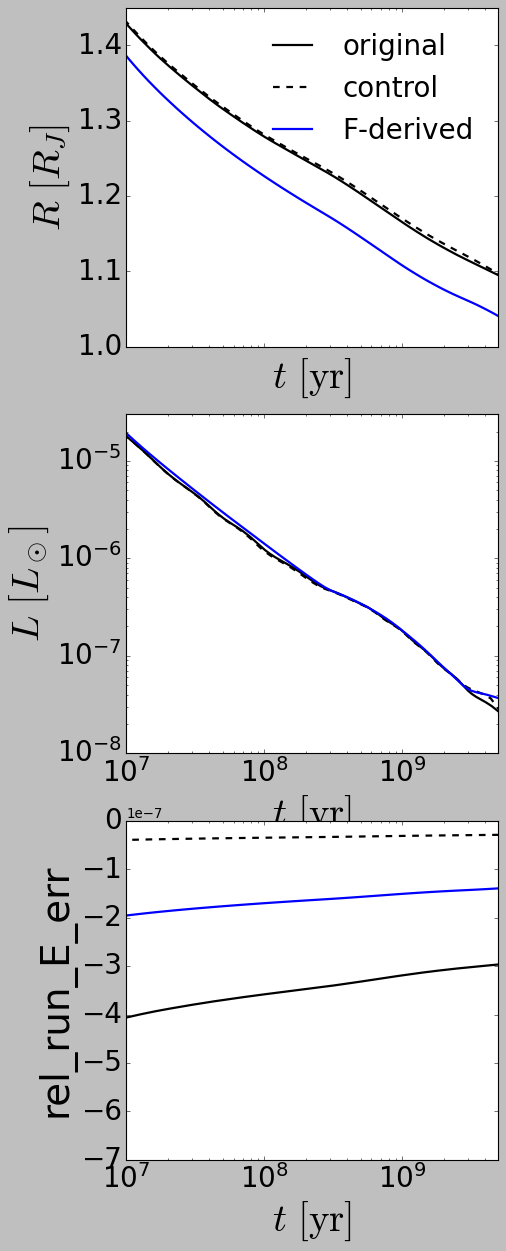

In [8]:
#fig, axes = plt.subplots(3,len(Minit),figsize=(24,16))
fig, axes = plt.subplots(3,1,figsize=(6,18))

for jj in range(3):
    axes[jj].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=35)
    axes[jj].set_xscale('log')
    axes[jj].set_xlim(1.e7,5.e9)

axes[0].set_ylabel(r"$R\ [R_J]$",fontsize=35)
axes[1].set_ylabel(r"$L\ [L_\odot]$",fontsize=35)
axes[2].set_ylabel("rel_run_E_err",fontsize=35)
    
axes[0].set_ylim(1.,1.45)

axes[1].set_yscale('log')
axes[1].set_ylim(1.e-8,3.e-5)


axes[0].set_xticklabels([])

    
for ax in np.ravel(axes):
    ax.tick_params(axis='both', which='major', labelsize=25)

for j, m in enumerate(Minit):
    for k, comp in enumerate(comps):
        for l, r in enumerate(Rinit):
            for ii, prof in enumerate(comp_profiles[0:1]):
                for jj, s in enumerate(Sinit):
                    #axes[0].set_title("{0} Mj, R_init = {1} Rj, {2} comp".format(m,r,comp),fontsize=16)
                    """
                    try:     
                        history_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/LOGS/planet_5.0Gyr_{0}_Mj_{1}_Rj_{2}_mespa.history".format(m,r,comp)
                        
                        history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
                    
                        axes[0,j].plot(history['star_age'],history['radius']*rSuntorJ,color='#008B8B',ls='-')
                        axes[1,j].plot(history['star_age'],history['luminosity'],color='#008B8B',ls='-',label='MESPA')
                        '''
                        profile_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/planet_5.0Gyr_{0}_Mj_{1}_Rj_{2}_mespa.profile".format(m,r,comp)
                        
                        profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
                    
                        axes[2,j].plot(profile['logT'],profile['logP']-6,color='#008B8B',ls='-',label='MESPA')
                        '''
                    except FileNotFoundError:
                        print("no mespa for {0}".format(m))
                    """
                    for i,e in enumerate(eos_choices):
            
                        try:
                            #history_filename = "./eos_{0}/planet_5.0Gyr_{1}_Mj_{2}_Rj_{3}_{4}_{5}.history".format(e,m,r,comp,prof,s)
                            history_filename = "./eos_{0}/planet_5.0Gyr_{1}_Mj_{2}_Rj_{3}.history".format(e,m,r,comp)
                            history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
                            #print(history['rel_run_E_err'])

                            
                            axes[0].plot(history['star_age'],history['radius']*rSuntorJ,color=colors[i],ls=ls[i],lw=2,label=labels[i])
                            #axes[0,j].plot(history['star_age'],history['Teff'],color=colors[i],ls=ls[i])
                            axes[1].plot(history['star_age'],history['luminosity'],color=colors[i],ls=ls[i],lw=2)
                            axes[2].plot(history['star_age'],history['rel_run_E_err'],color=colors[i],ls=ls[i],lw=2)

                            '''
                            profile_filename = "./eos_{0}/planet_1.0Gyr_{1}_Mj_{2}.profile".format(e,m,comp)
                            profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
                
                            axes[2,j].plot(profile['logT'],profile['logP']-6,color=colors[i],ls=ls[i],label=e)
                            '''
                            #axes[0,ii].legend(loc='upper right',frameon=False,fontsize=12)
                        except FileNotFoundError:
                            print("no {0}".format(e))

axes[0].legend(loc='upper right',frameon=False,fontsize=25)
plt.subplots_adjust(hspace=0.2)
plt.show()
#plt.savefig("../paper_figures/prelim_protosolar_MESA_tracks.pdf",bbox_inches='tight')

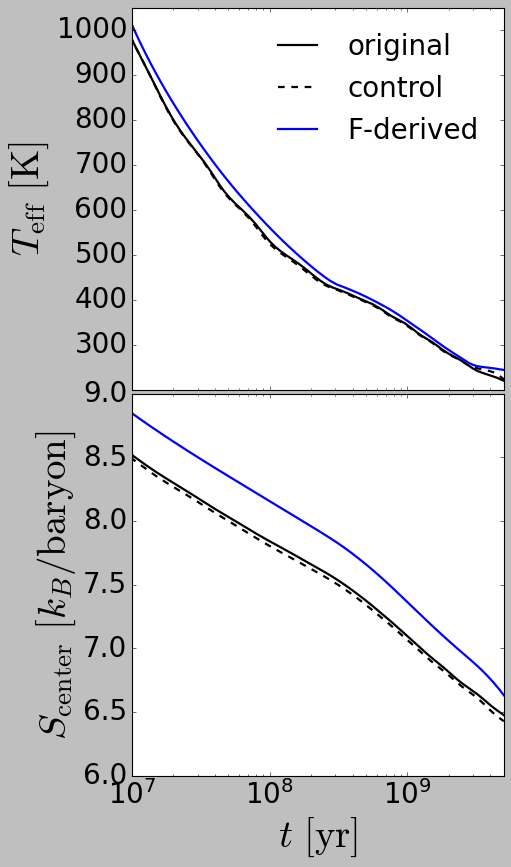

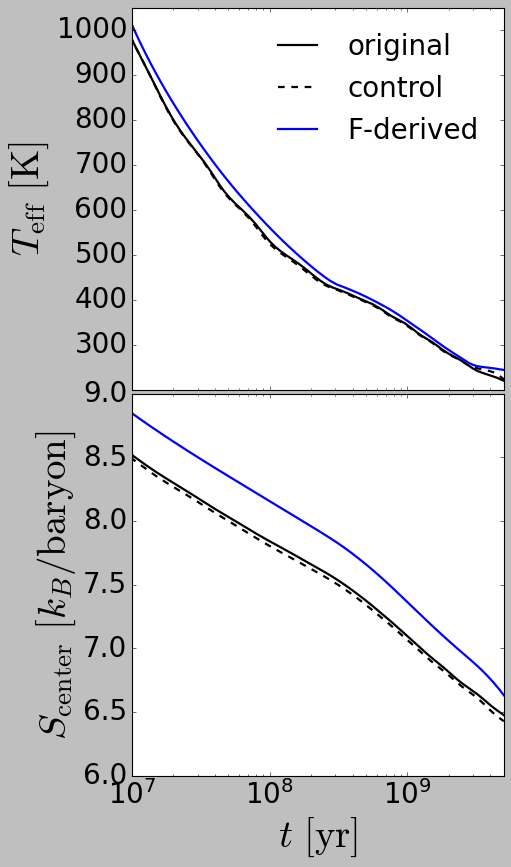

In [25]:
#fig, axes = plt.subplots(3,len(Minit),figsize=(24,16))
fig, axes = plt.subplots(2,1,figsize=(6,12))

for jj in range(2):
    axes[jj].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=35)
    axes[jj].set_xscale('log')
    axes[jj].set_xlim(1.e7,5.e9)

axes[0].set_ylabel(r"$T_{\mathrm{eff}}\ \mathrm{[K]}$",fontsize=35)
axes[1].set_ylabel(r"$S_{\mathrm{center}}\ [k_B/\mathrm{baryon}]$",fontsize=35)
    
axes[0].set_ylim(200,1050)
axes[1].set_ylim(6.,9.)

#axes[1].set_yscale('log')
#axes[1].set_ylim(1.e-8,3.e-5)

axes[0].set_xticklabels([])
axes[0].set_yticks(np.arange(300,1100,100))


    
for ax in np.ravel(axes):
    ax.tick_params(axis='both', which='major', labelsize=25)

for j, m in enumerate(Minit):
    for k, comp in enumerate(comps):
        for l, r in enumerate(Rinit):
            for ii, prof in enumerate(comp_profiles[0:1]):
                for jj, s in enumerate(Sinit):
                    #axes[0].set_title("{0} Mj, R_init = {1} Rj, {2} comp".format(m,r,comp),fontsize=16)
                    """
                    try:     
                        history_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/LOGS/planet_5.0Gyr_{0}_Mj_{1}_Rj_{2}_mespa.history".format(m,r,comp)
                        
                        history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
                    
                        axes[0,j].plot(history['star_age'],history['radius']*rSuntorJ,color='#008B8B',ls='-')
                        axes[1,j].plot(history['star_age'],history['luminosity'],color='#008B8B',ls='-',label='MESPA')
                        '''
                        profile_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/planet_5.0Gyr_{0}_Mj_{1}_Rj_{2}_mespa.profile".format(m,r,comp)
                        
                        profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
                    
                        axes[2,j].plot(profile['logT'],profile['logP']-6,color='#008B8B',ls='-',label='MESPA')
                        '''
                    except FileNotFoundError:
                        print("no mespa for {0}".format(m))
                    """
                    for i,e in enumerate(eos_choices):
            
                        try:
                            #history_filename = "./eos_{0}/planet_5.0Gyr_{1}_Mj_{2}_Rj_{3}_{4}_{5}.history".format(e,m,r,comp,prof,s)
                            history_filename = "./eos_{0}/planet_5.0Gyr_{1}_Mj_{2}_Rj_{3}.history".format(e,m,r,comp)
                            history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
                            #print(history['rel_run_E_err'])

                            
                            axes[0].plot(history['star_age'],history['Teff'],color=colors[i],ls=ls[i],lw=2,label=labels[i])
                            #axes[0,j].plot(history['star_age'],history['Teff'],color=colors[i],ls=ls[i])
                            axes[1].plot(history['star_age'],history['center_entropy'],color=colors[i],ls=ls[i],lw=2)


                            '''
                            profile_filename = "./eos_{0}/planet_1.0Gyr_{1}_Mj_{2}.profile".format(e,m,comp)
                            profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
                
                            axes[2,j].plot(profile['logT'],profile['logP']-6,color=colors[i],ls=ls[i],label=e)
                            '''
                            #axes[0,ii].legend(loc='upper right',frameon=False,fontsize=12)
                        except FileNotFoundError:
                            print("no {0}".format(e))

axes[0].legend(loc='upper right',frameon=False,fontsize=25)
plt.subplots_adjust(hspace=0.01)
plt.show()
#plt.savefig("../paper_figures/prelim_protosolar_MESA_tracks_Teff_entropy.pdf",bbox_inches='tight')

In [26]:
orig_history = Table.read("./eos_CMS19_orig_meos_implementation/planet_5.0Gyr_5.0_Mj_2.0_Rj_protosolar.history", format="ascii", header_start=4, data_start=5)

TC_history = Table.read("./eos_CMS19_TC_s=2/planet_5.0Gyr_5.0_Mj_2.0_Rj_protosolar.history", format="ascii", header_start=4, data_start=5)

control_history = Table.read("./eos_CMS19_control_s=2_sf=0.1/planet_5.0Gyr_5.0_Mj_2.0_Rj_protosolar.history", format="ascii", header_start=4, data_start=5)

standard_log10age = np.arange(7.0,9.8,0.1)

standard_TC_R =  np.interp(standard_log10age,np.log10(TC_history['star_age']),TC_history['radius'])
standard_orig_R =np.interp(standard_log10age,np.log10(orig_history['star_age']),orig_history['radius'])

print(np.mean(100*(standard_TC_R - standard_orig_R)/standard_orig_R))


standard_TC_L =  np.interp(standard_log10age,np.log10(TC_history['star_age']),TC_history['luminosity'])
standard_orig_L =np.interp(standard_log10age,np.log10(orig_history['star_age']),orig_history['luminosity'])

print(np.mean(100*(standard_TC_L - standard_orig_L)/standard_orig_L))


standard_TC_Teff =  np.interp(standard_log10age,np.log10(TC_history['star_age']),TC_history['Teff'])
standard_orig_Teff =np.interp(standard_log10age,np.log10(orig_history['star_age']),orig_history['Teff'])

print(np.mean(100*(standard_TC_Teff - standard_orig_Teff)/standard_orig_Teff))

standard_TC_S =  np.interp(standard_log10age,np.log10(TC_history['star_age']),TC_history['center_entropy'])
standard_orig_S =np.interp(standard_log10age,np.log10(orig_history['star_age']),orig_history['center_entropy'])

print(np.mean(100*(standard_TC_S - standard_orig_S)/standard_orig_S))


-4.310927291150594
8.530257317591879
4.280415171318949
3.722983981771922


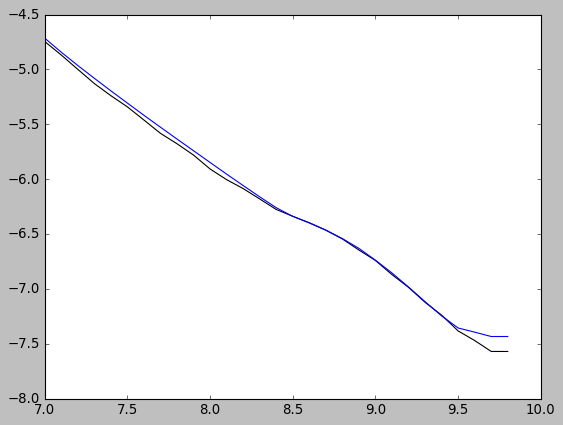

In [30]:
fig, ax = plt.subplots(1,1,figsize=(8,6))
ax.plot(standard_log10age, np.log10(standard_orig_L),'k-')

ax.plot(standard_log10age, np.log10(standard_TC_L),'b-')
plt.show()

In [42]:
orig = Table.read("./eos_CMS19_orig_meos_implementation/planet_5.0_Mj_2.0_Rj_protosolar.terminationprofile", format="ascii", header_start=4, data_start=5)

TC = Table.read("./eos_CMS19_TC_s=2/planet_5.0_Mj_2.0_Rj_protosolar.terminationprofile", format="ascii", header_start=4, data_start=5)

control = Table.read("./eos_CMS19_control_s=2_sf=0.1/planet_5.0_Mj_2.0_Rj_protosolar.terminationprofile", format="ascii", header_start=4, data_start=5)



In [43]:
print(orig.colnames)

['zone', 'mass', 'logR', 'logT', 'logRho', 'logP', 'x_mass_fraction_H', 'y_mass_fraction_He', 'z_mass_fraction_metals', 'dm', 'q', 'xq', 'radius', 'rmid', 'acoustic_radius', 'temperature', 'energy', 'entropy', 'pressure', 'prad', 'pgas', 'grada', 'log_csound', 'h1', 'he3', 'he4', 'c12', 'n14', 'o16', 'ne20', 'mg24', 'total_energy', 'ergs_error', 'ergs_error_integral', 'ergs_rel_error_integral', 'dm_eps_grav', 'dE', 'log_rel_E_err', 'gradT', 'gradr', 'gradL', 'sch_stable', 'ledoux_stable', 'mixing_type', 'tau', 'brunt_N2', 'brunt_N2_structure_term', 'brunt_N2_composition_term', 'log_brunt_N2_structure_term', 'log_brunt_N2_composition_term', 'brunt_A', 'brunt_A_div_x2', 'brunt_N2_dimensionless', 'brunt_N_dimensionless', 'brunt_frequency', 'brunt_N', 'log_brunt_N', 'log_brunt_N2', 'log_brunt_N2_dimensionless', 'brunt_B', 'brunt_nonB', 'log_brunt_B', 'log_brunt_nonB', 'sign_brunt_N2', 'brunt_nu', 'log_brunt_nu', 'lamb_S', 'lamb_S2', 'lamb_Sl1', 'lamb_Sl2', 'lamb_Sl3', 'lamb_Sl10', 'log_lam

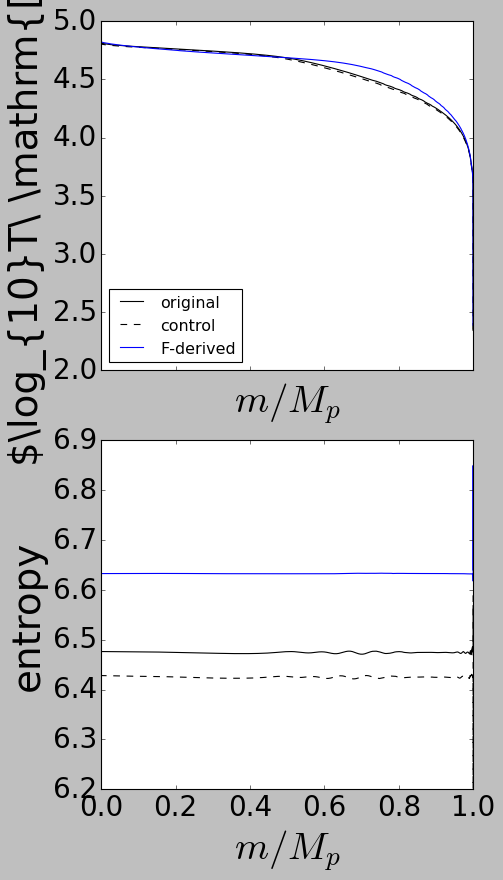

In [45]:
fig, axes = plt.subplots(2,1,figsize=(6,12))

axes[0].plot(orig['q'],orig['logT'],'k-',label='original')
axes[0].plot(control['q'],control['logT'],'k--',label='control')
axes[0].plot(TC['q'],TC['logT'],'b-',label='F-derived')


axes[1].plot(orig['q'],orig['entropy'],'k-',label='original')
axes[1].plot(control['q'],control['entropy'],'k--',label='control')
axes[1].plot(TC['q'],TC['entropy'],'b-',label='F-derived')

for ax in axes:
    ax.set_xlabel(r"$m/M_p$",fontsize=35)
    
axes[0].set_xticklabels([])
axes[0].set_ylabel(r"$\log_{10}T\ \mathrm{[K]}",fontsize=35)
axes[1].set_ylabel("entropy",fontsize=35)

    
for ax in np.ravel(axes):
    ax.tick_params(axis='both', which='major', labelsize=25)


axes[0].legend(loc='lower left')

plt.show()

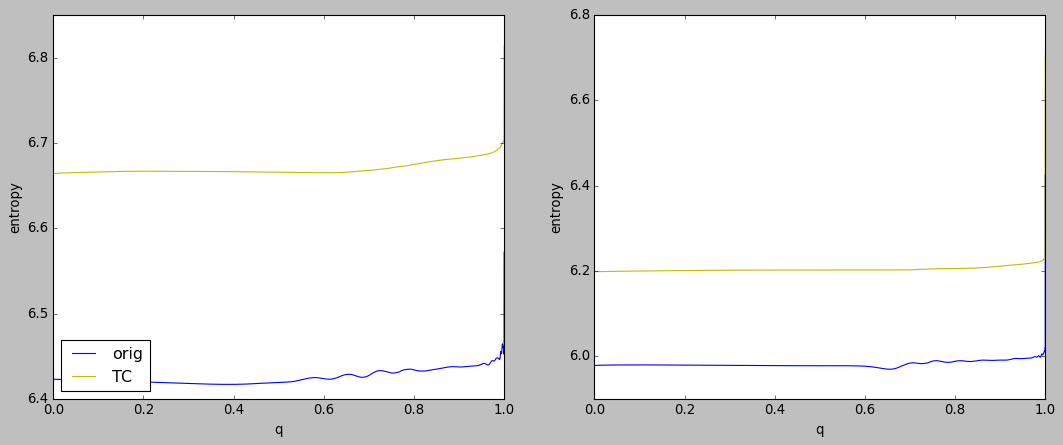

In [191]:
fig, axes = plt.subplots(1,2,figsize=(16,6))

axes[0].plot(orig_uniform['q'],orig_uniform['entropy'],'b-',label='orig')
axes[0].plot(TC_uniform['q'],TC_uniform['entropy'],'y-',label='TC')

axes[1].plot(orig_exp['q'],orig_exp['entropy'],'b-')
axes[1].plot(TC_exp['q'],TC_exp['entropy'],'y-')

for ax in axes:
    ax.set_xlabel("q")
    ax.set_ylabel("entropy")
    #ax.set_ylim(-0.05,1.05)

axes[0].legend(loc='lower left')

plt.show()

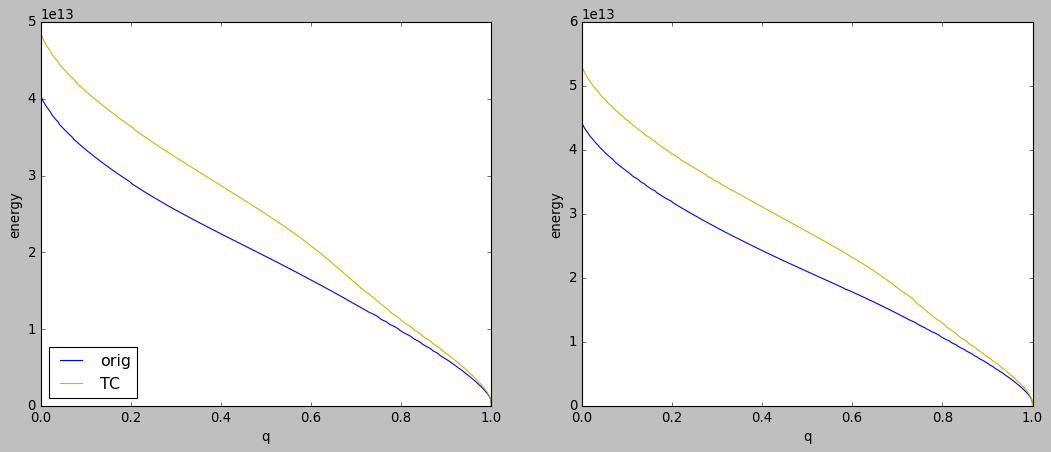

In [190]:
fig, axes = plt.subplots(1,2,figsize=(16,6))

axes[0].plot(orig_uniform['q'],orig_uniform['energy'],'b-',label='orig')
axes[0].plot(TC_uniform['q'],TC_uniform['energy'],'y-',label='TC')

axes[1].plot(orig_exp['q'],orig_exp['energy'],'b-')
axes[1].plot(TC_exp['q'],TC_exp['energy'],'y-')

for ax in axes:
    ax.set_xlabel("q")
    ax.set_ylabel("energy")
    #ax.set_ylim(-0.05,1.05)

axes[0].legend(loc='lower left')

plt.show()

no CMS19_control_s=2_sf=0.25
no CMS19_control_s=2_sf=0.25
no CMS19_control_s=2_sf=0.25
no CMS19_control_s=2_sf=0.25
no CMS19_control_s=1_sf=0.25
no CMS19_control_s=2_sf=0.25


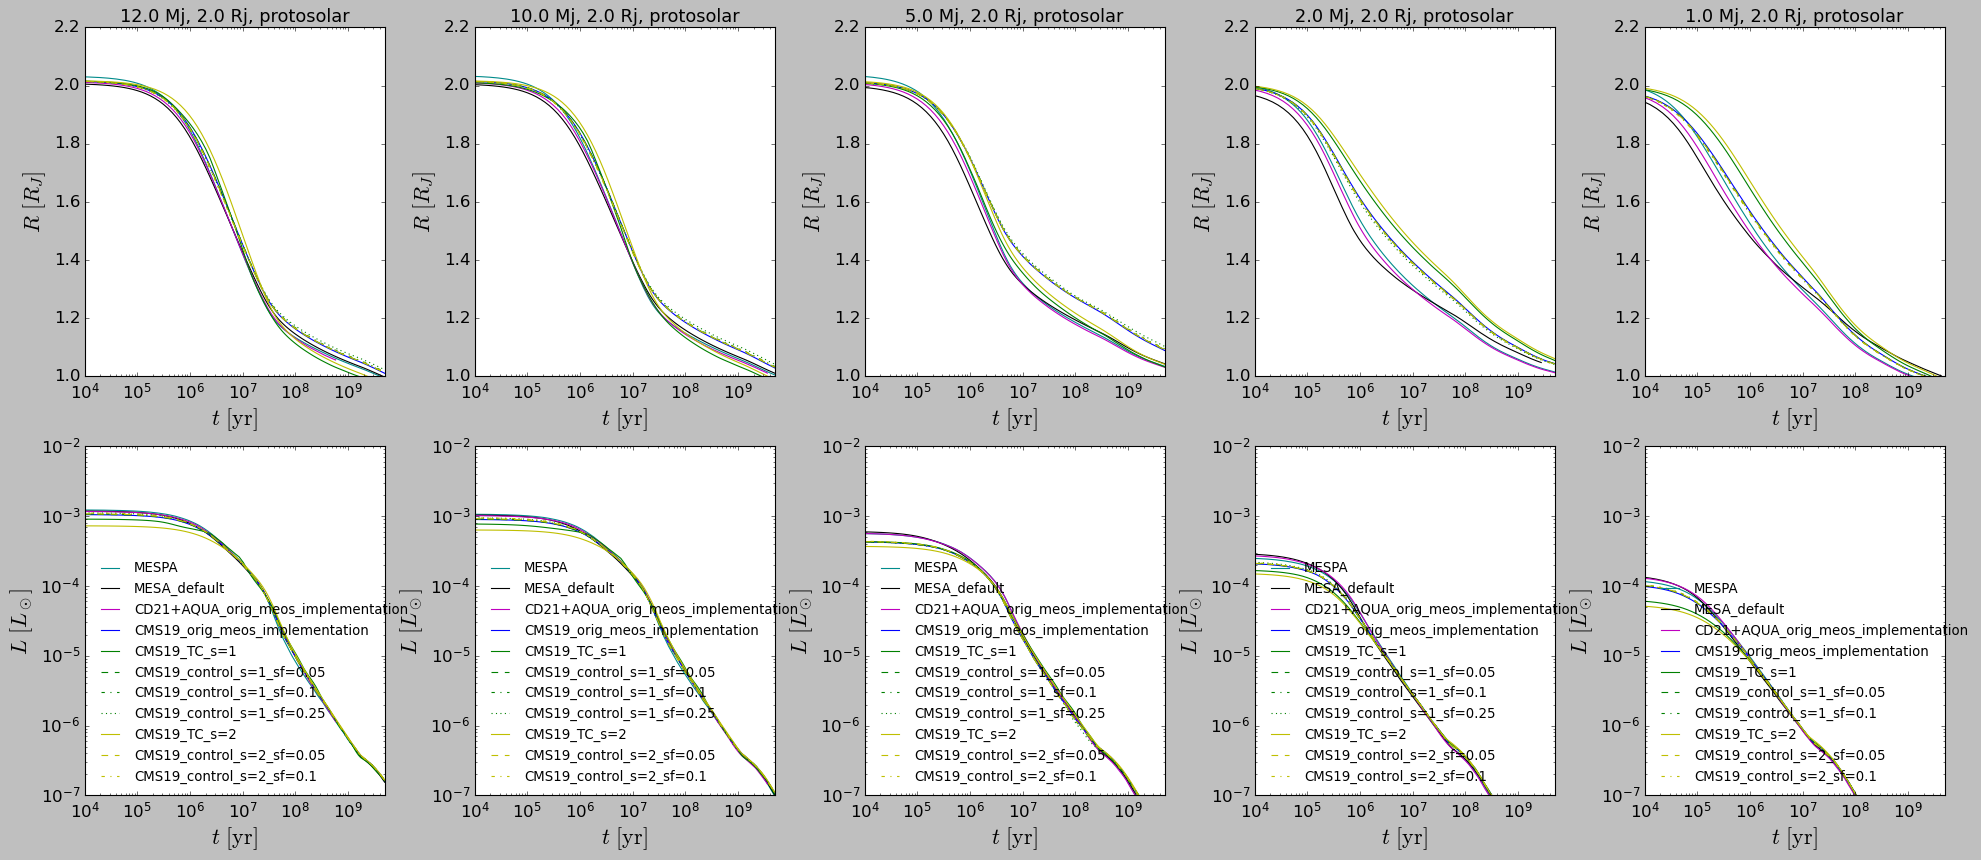

In [40]:
#fig, axes = plt.subplots(3,len(Minit),figsize=(24,16))
fig, axes = plt.subplots(2,len(Minit),figsize=(6*len(Minit),6*2))

for ii in range(len(Minit)):
    axes[0,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
    axes[0,ii].set_ylabel(r"$R\ [R_J]$",fontsize=20)
    axes[1,ii].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
    axes[1,ii].set_ylabel(r"$L\ [L_\odot]$",fontsize=20)
    #axes[2,ii].set_xlabel(r"$\log_{10}T\ [\mathrm{K}]$",fontsize=20)
    #axes[2,ii].set_ylabel(r"$\log_{10}P\ [\mathrm{bar}]$",fontsize=20)
    
    axes[0,ii].set_xscale('log')
    axes[1,ii].set_xscale('log')
    axes[1,ii].set_yscale('log')
    axes[0,ii].set_xlim(1.e4,5.e9)
    axes[0,ii].set_ylim(1.,2.2)
    #axes[0,ii].set_ylim(1.,5.1)
    axes[1,ii].set_xlim(1.e4,5.e9)
    axes[1,ii].set_ylim(1.e-7,1.e-2)
    
    #axes[2,ii].invert_yaxis()

for ax in np.ravel(axes):
    ax.tick_params(axis='both', which='major', labelsize=15)

for j, m in enumerate(Minit):
    for k, comp in enumerate(comps[1:2]):
        for l, r in enumerate(Rinit[0:1]):
            axes[0,j].set_title("{0} Mj, {1} Rj, {2}".format(m,r,comp),fontsize=16)
            try:     
                history_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/LOGS/planet_5.0Gyr_{0}_Mj_{1}_Rj_{2}_mespa.history".format(m,r,comp)
                
                history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
            
                axes[0,j].plot(history['star_age'],history['radius']*rSuntorJ,color='#008B8B',ls='-')
                axes[1,j].plot(history['star_age'],history['luminosity'],color='#008B8B',ls='-',label='MESPA')
                '''
                profile_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/planet_5.0Gyr_{0}_Mj_{1}_Rj_{2}_mespa.profile".format(m,r,comp)
                
                profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
            
                axes[2,j].plot(profile['logT'],profile['logP']-6,color='#008B8B',ls='-',label='MESPA')
                '''
            except FileNotFoundError:
                print("no mespa for {0}".format(m))
        
            for i,e in enumerate(eos_choices):
    
                try:
                    history_filename = "./eos_{0}/planet_5.0Gyr_{1}_Mj_{2}_Rj_{3}.history".format(e,m,r,comp)
                    history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
        
                    axes[0,j].plot(history['star_age'],history['radius']*rSuntorJ,color=colors[i],ls=ls[i])
                    axes[1,j].plot(history['star_age'],history['luminosity'],color=colors[i],ls=ls[i],label=e)
    
                    #print(e)
                    #print(history['radius']*rSuntorJ)
                    #print(history['luminosity'])
                    '''
                    profile_filename = "./eos_{0}/planet_1.0Gyr_{1}_Mj_{2}.profile".format(e,m,comp)
                    profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
        
                    axes[2,j].plot(profile['logT'],profile['logP']-6,color=colors[i],ls=ls[i],label=e)
                    '''
                    axes[1,j].legend(loc='lower left',frameon=False,fontsize=12)
                except FileNotFoundError:
                    print("no {0}".format(e))
            
plt.subplots_adjust(hspace=0.2,wspace=0.3)
plt.show()

In [6]:
# eos names
eos_choices = ['MESA_default','CD21+AQUA_orig_meos_implementation','CMS19_orig_meos_implementation','CMS19_TC_s=1','CD21_Y0275']
comps = ['platowg']

Minit = np.atleast_1d(np.array((1.0)))
Rinit = np.array((2.0,5.0))

age = 5.0e9
agestr = str(np.round(age/1.e9, 1))
print(agestr)

5.0


../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/LOGS/planet_5.0Gyr_1.0_Mj_2.0_Rj_platowg_mespa.history
no MESA_default


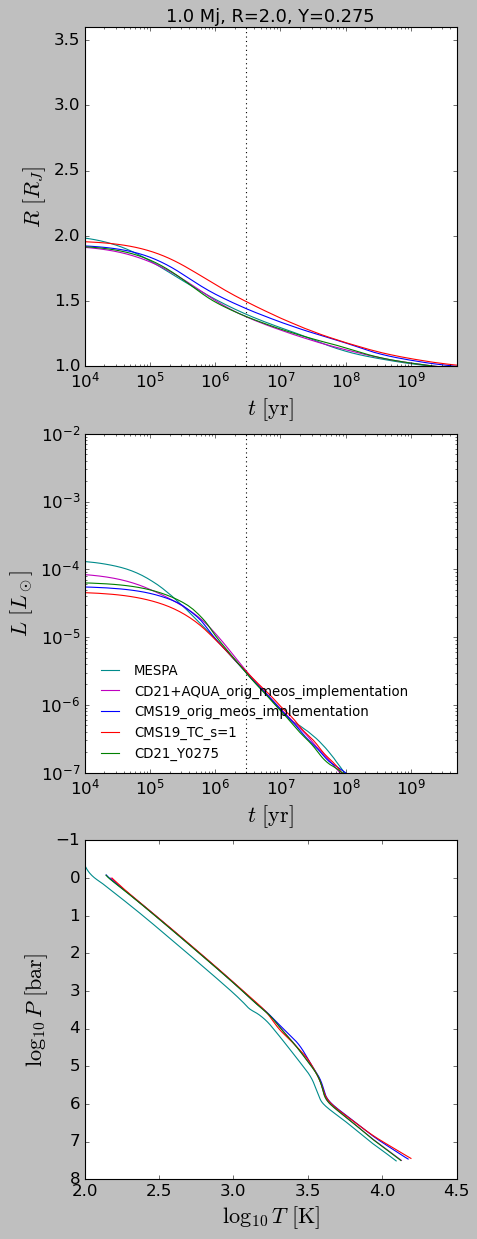

In [21]:
# for Jupiter models

fig, axes = plt.subplots(3,1,figsize=(6,18))
axes[0].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
axes[0].set_ylabel(r"$R\ [R_J]$",fontsize=20)
axes[1].set_xlabel(r"$t\ [\mathrm{yr}]$",fontsize=20)
axes[1].set_ylabel(r"$L\ [L_\odot]$",fontsize=20)
axes[2].set_xlabel(r"$\log_{10}T\ [\mathrm{K}]$",fontsize=20)
axes[2].set_ylabel(r"$\log_{10}P\ [\mathrm{bar}]$",fontsize=20)
    
axes[0].set_xscale('log')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[0].set_xlim(1.e4,5.e9)
axes[0].set_ylim(1.,3.6)
axes[1].set_xlim(1.e4,5.e9)
axes[1].set_ylim(1.e-7,1.e-2)
    
axes[2].invert_yaxis()

for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=15)

for ax in axes[0:2]:
    ax.axvline(3.e6,color='k',ls=':')

for k, comp in enumerate(comps):
    for l, r in enumerate(Rinit[0:1]):
        axes[0].set_title("1.0 Mj, R={0}, Y=0.275".format(r),fontsize=16)
        try:     
            history_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/LOGS/planet_5.0Gyr_1.0_Mj_{0}_Rj_{1}_mespa.history".format(r,comp)
            print(history_filename)
                
            history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
            
            axes[0].plot(history['star_age'],history['radius']*rSuntorJ,color='#008B8B',ls='-')
            axes[1].plot(history['star_age'],history['luminosity'],color='#008B8B',ls='-',label='MESPA')
            
            profile_filename = "../../../test_MESPA/mespa-main/test_suite/mespa_CD21+water+rock/planet_5.0Gyr_1.0_Mj_{0}_Rj_{1}_mespa.profile".format(r,comp)
                
            profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
            
            axes[2].plot(profile['logT'],profile['logP']-6,color='#008B8B',ls='-',label='MESPA')
            
        except FileNotFoundError:
            print("no mespa for {0}".format(m))
        
        for i,e in enumerate(eos_choices):
    
            try:
                history_filename = "./eos_{0}/planet_5.0Gyr_1.0_Mj_{1}_Rj_{2}_customatm.history".format(e,r,comp)
                history = Table.read(history_filename, format="ascii", header_start=4, data_start=5)
        
                axes[0].plot(history['star_age'],history['radius']*rSuntorJ,color=colors[i],ls=ls[i])
                axes[1].plot(history['star_age'],history['luminosity'],color=colors[i],ls=ls[i],label=e)
    
                profile_filename = "./eos_{0}/planet_1.0_Mj_{1}_Rj_{2}_customatm.terminationprofile".format(e,r,comp)
                profile = Table.read(profile_filename, format="ascii", header_start=4, data_start=5)
        
                axes[2].plot(profile['logT'],profile['logP']-6,color=colors[i],ls=ls[i],label=e)
    
                axes[1].legend(loc='lower left',frameon=False,fontsize=12)
            except FileNotFoundError:
                print("no {0}".format(e))
            
plt.subplots_adjust(hspace=0.2,wspace=0.3)
plt.show()